# VMD: `store_history` comparison

This example compares classic VMD (`store_history=True`, full spectral history)
with the low-memory path (`store_history=False`, rolling buffers) on the **same** signal.

We look at:
1. wall-clock time
2. reconstruction error
3. mode waveforms / spectra
4. numerical difference between the two outputs

For long signals, prefer `store_history=False` to avoid large `(max_iter, T, K)` allocations.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

from pysdkit import VMD
from pysdkit.data import test_vmd
from pysdkit.plot import plot_IMFs

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False

## 1. Same input signal

Use the packaged multi-component VMD demo (`test_vmd()`).

length = 1024, fs = 1024.0
K = 4, alpha = 2000, max_iter = 500


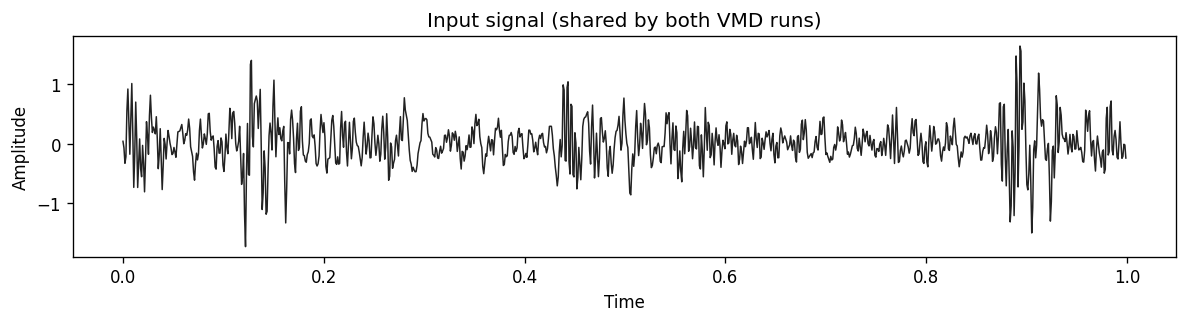

In [2]:
t, signal, fs = test_vmd()
K = 4
alpha = 2000
tau = 0.0
max_iter = 500
tol = 1e-6

print(f"length = {signal.size}, fs = {fs:.1f}")
print(f"K = {K}, alpha = {alpha}, max_iter = {max_iter}")

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(t, signal, color="#222", lw=0.9)
ax.set_title("Input signal (shared by both VMD runs)")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 2. Run both modes and measure performance

In [3]:
import time


def run_vmd(store_history: bool):
    vmd = VMD(
        alpha=alpha,
        K=K,
        tau=tau,
        init="uniform",
        max_iter=max_iter,
        tol=tol,
        store_history=store_history,
    )
    t0 = time.perf_counter()
    u, u_hat, omega = vmd.fit_transform(signal, return_all=True)
    elapsed = time.perf_counter() - t0
    recon = np.sum(u, axis=0)
    # align length if odd-sample trim happened
    x = signal[: recon.size]
    rel_err = np.linalg.norm(recon - x) / (np.linalg.norm(x) + 1e-12)
    return {
        "u": u,
        "u_hat": u_hat,
        "omega": omega,
        "recon": recon,
        "elapsed": elapsed,
        "rel_err": rel_err,
        "n_omega": omega.shape[0],
        "store_history": store_history,
    }


full = run_vmd(True)
low = run_vmd(False)

print("store_history |  time (s)  | rel. recon err | omega rows")
print("-" * 58)
for r in (full, low):
    print(
        f"{str(r['store_history']):>13} | {r['elapsed']:10.4f} | "
        f"{r['rel_err']:14.3e} | {r['n_omega']:10d}"
    )

diff_modes = np.linalg.norm(full["u"] - low["u"]) / (np.linalg.norm(full["u"]) + 1e-12)
diff_recon = np.linalg.norm(full["recon"] - low["recon"]) / (
    np.linalg.norm(full["recon"]) + 1e-12
)
print(f"\nrelative ||IMFs_full - IMFs_low|| = {diff_modes:.3e}")
print(f"relative ||recon_full - recon_low|| = {diff_recon:.3e}")

store_history |  time (s)  | rel. recon err | omega rows
----------------------------------------------------------
         True |     0.1054 |      2.199e-01 |        498
        False |     0.0053 |      2.199e-01 |         24

relative ||IMFs_full - IMFs_low|| = 1.591e-04
relative ||recon_full - recon_low|| = 9.810e-05


## 3. Side-by-side IMF visualization

store_history=True (full history)


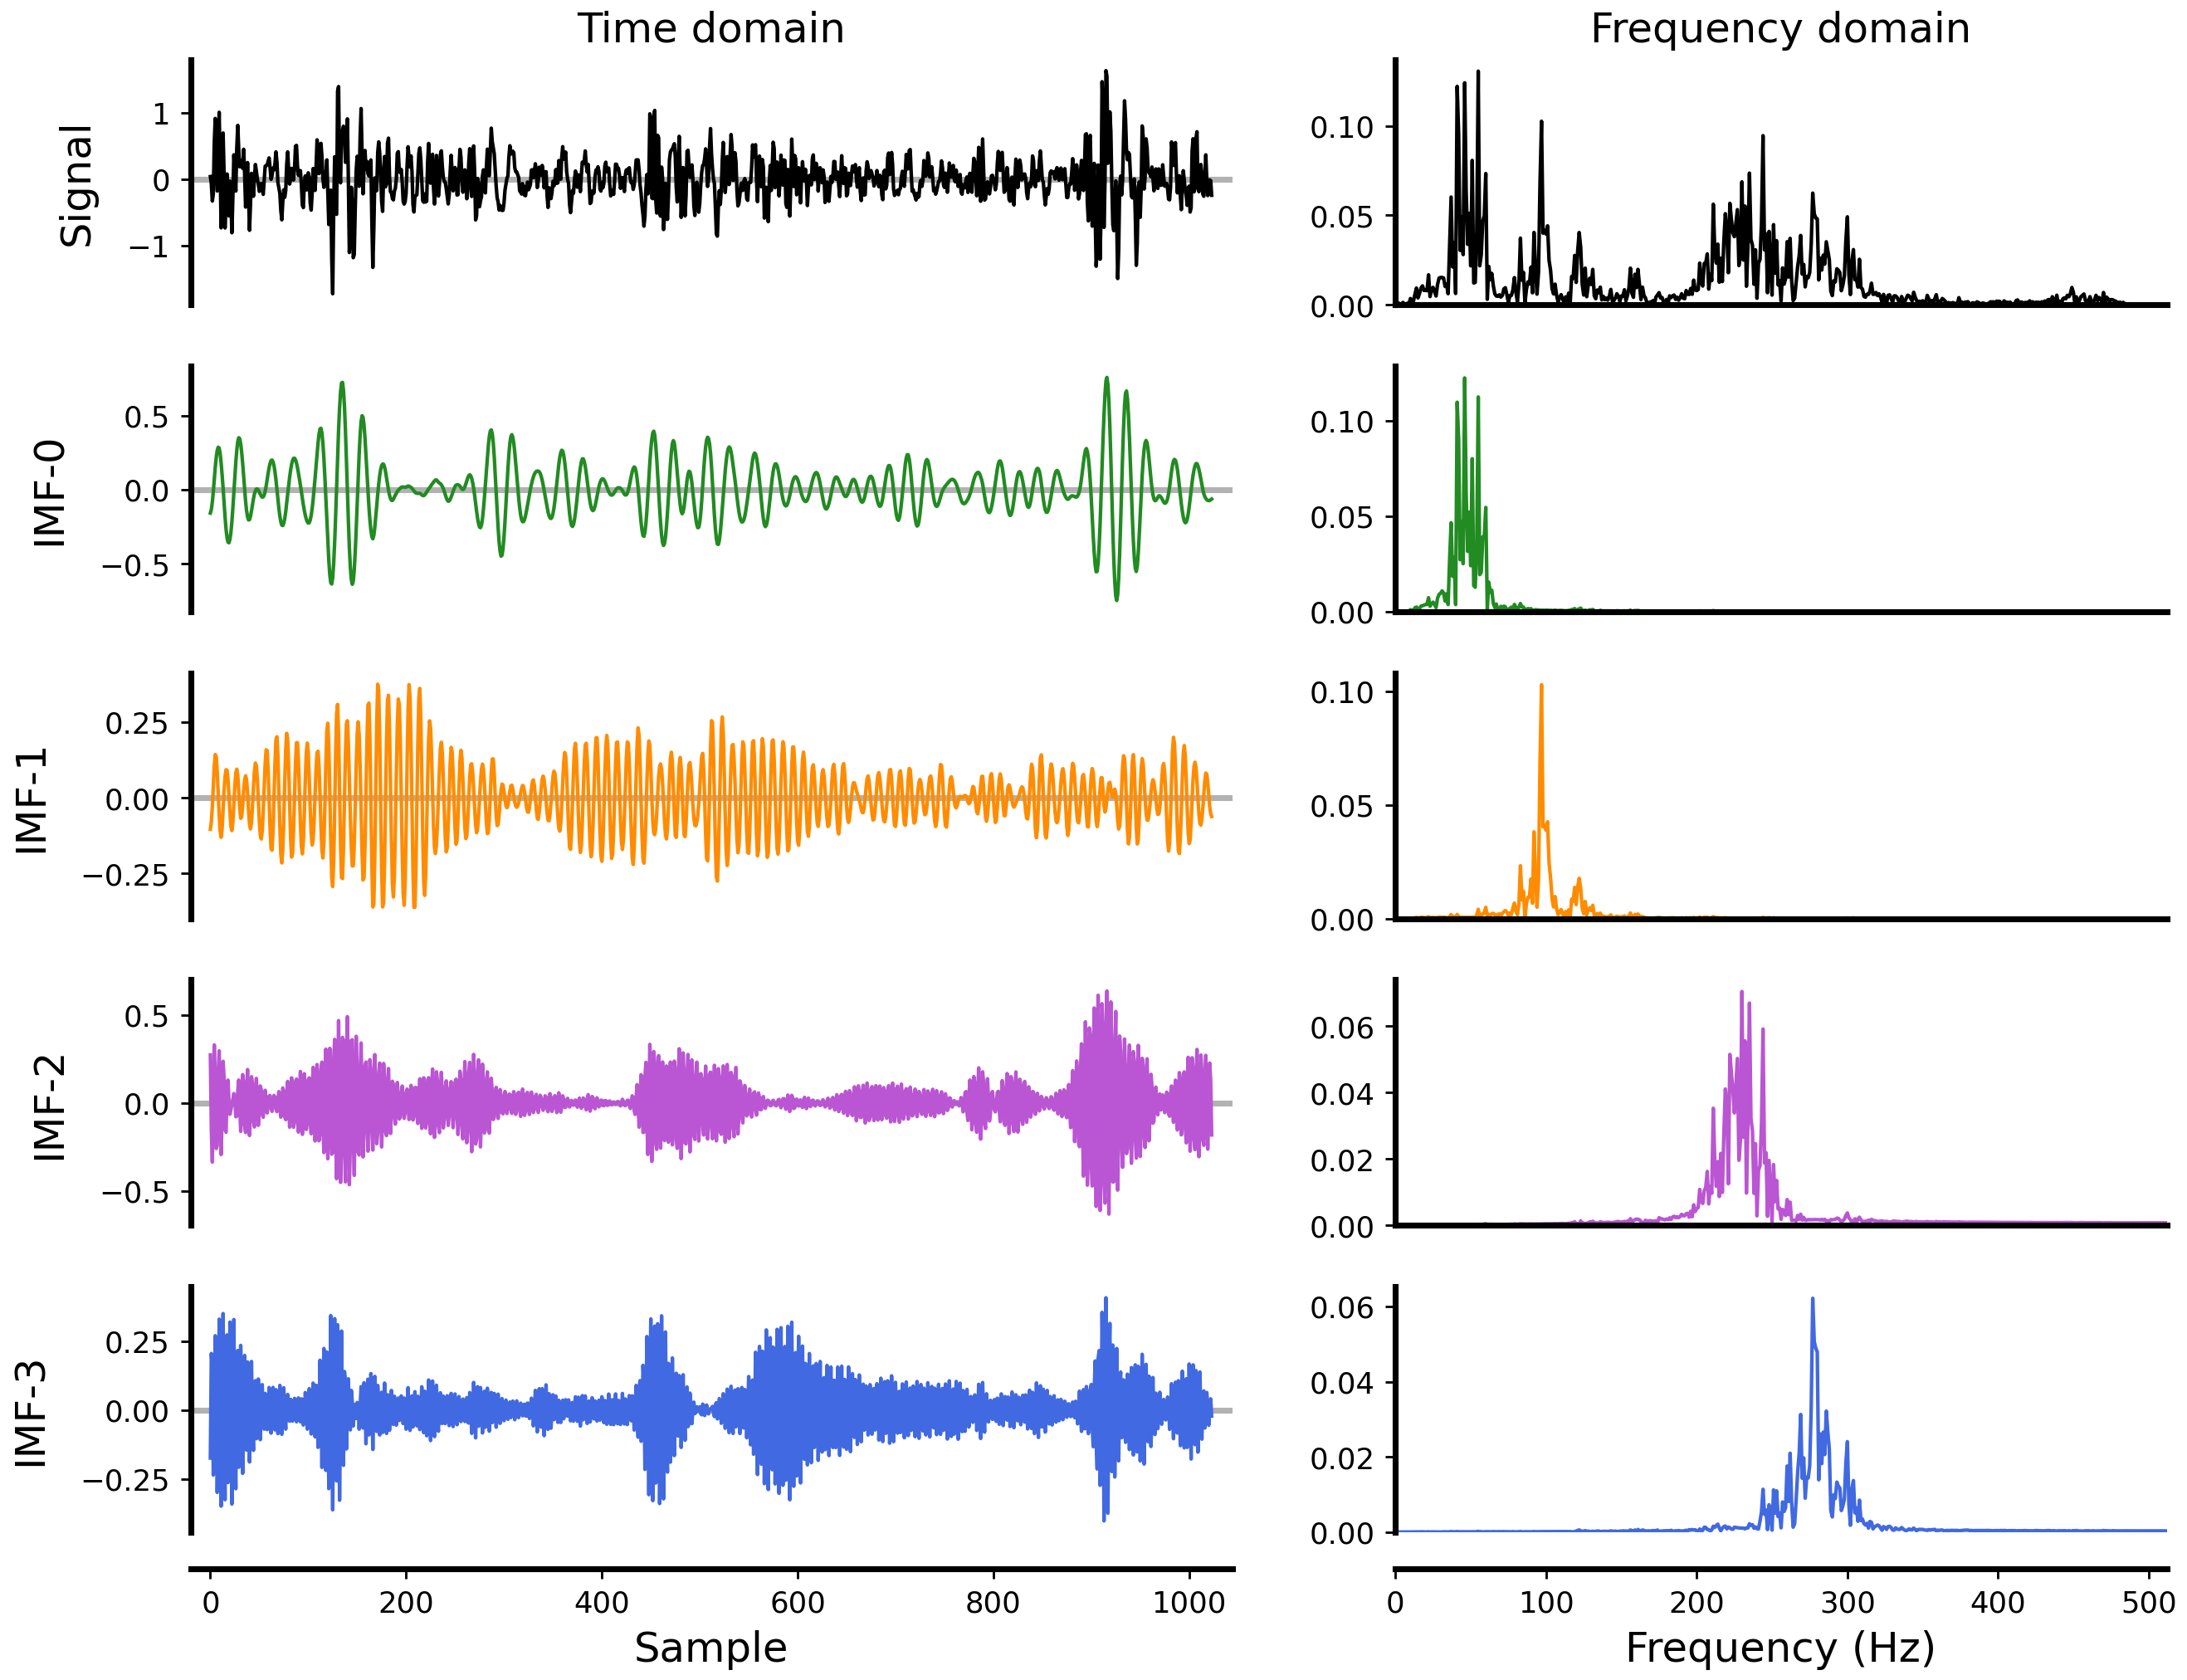

store_history=False (low memory)


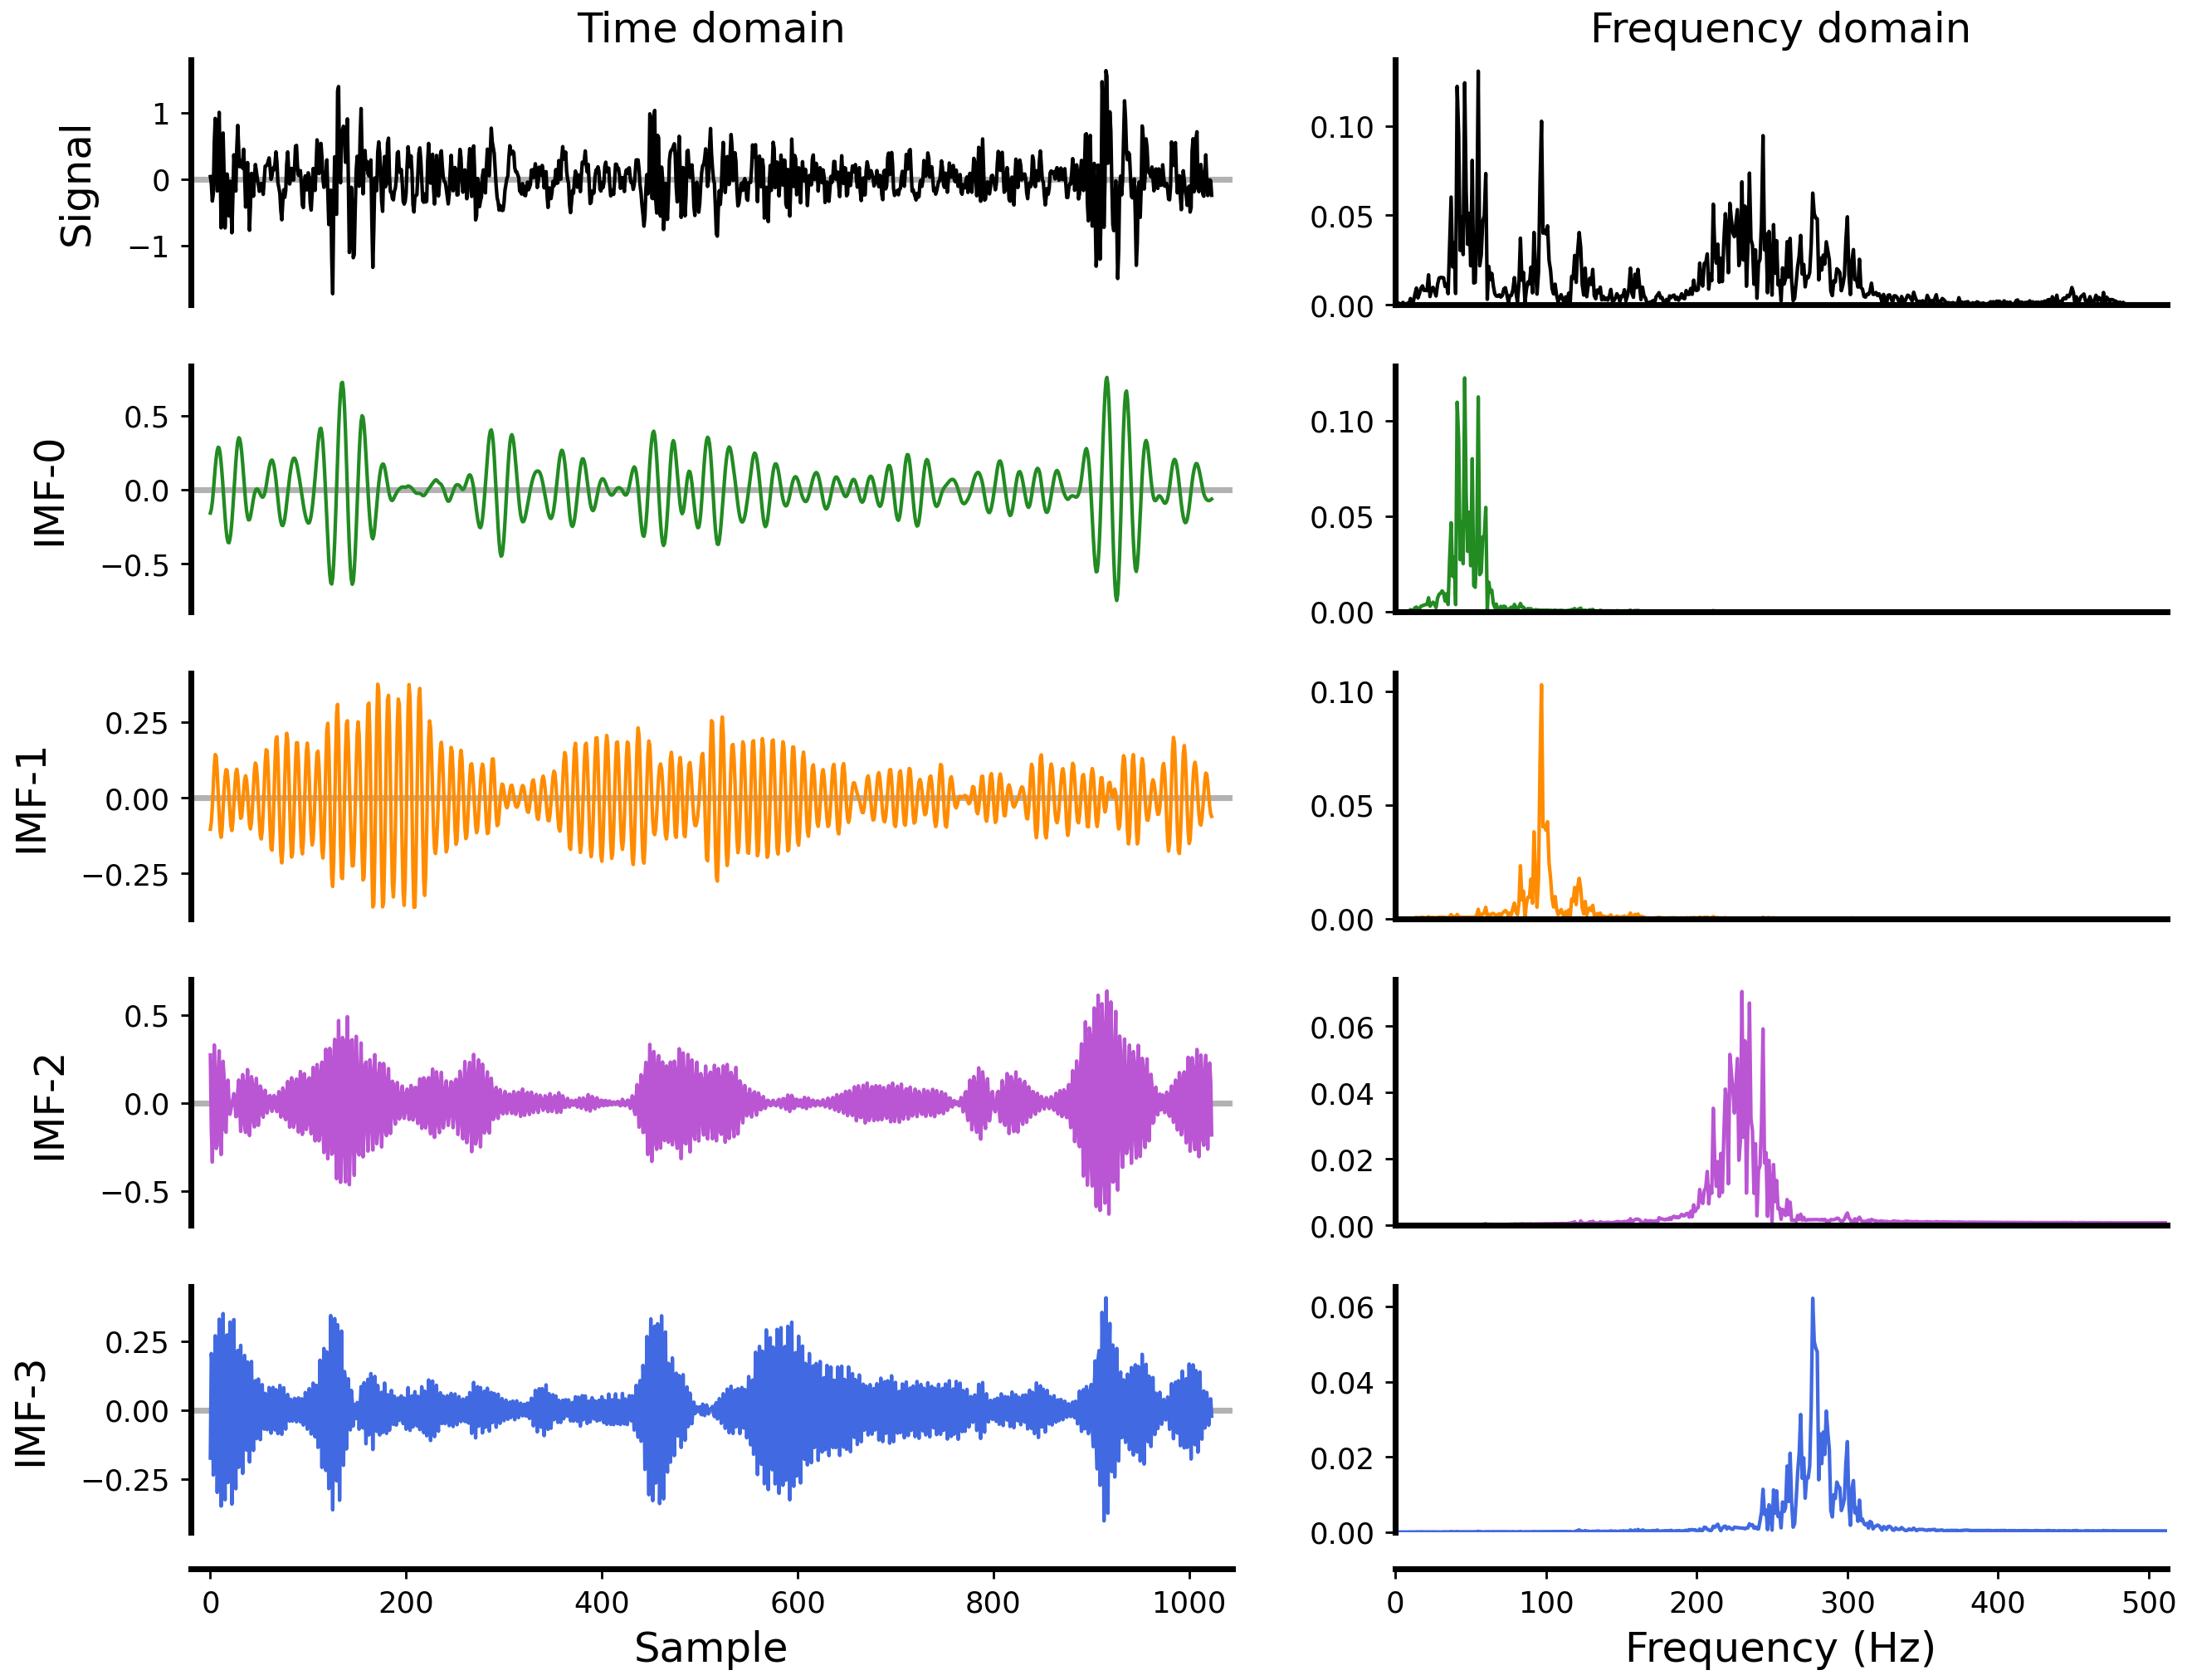

In [4]:
x = signal[: full["recon"].size]

print("store_history=True (full history)")
plot_IMFs(x, full["u"], view="2d_freq", fs=fs, freq_max=fs / 2)
plt.show()

print("store_history=False (low memory)")
plot_IMFs(x, low["u"], view="2d_freq", fs=fs, freq_max=fs / 2)
plt.show()

## 4. Overlay modes to inspect differences

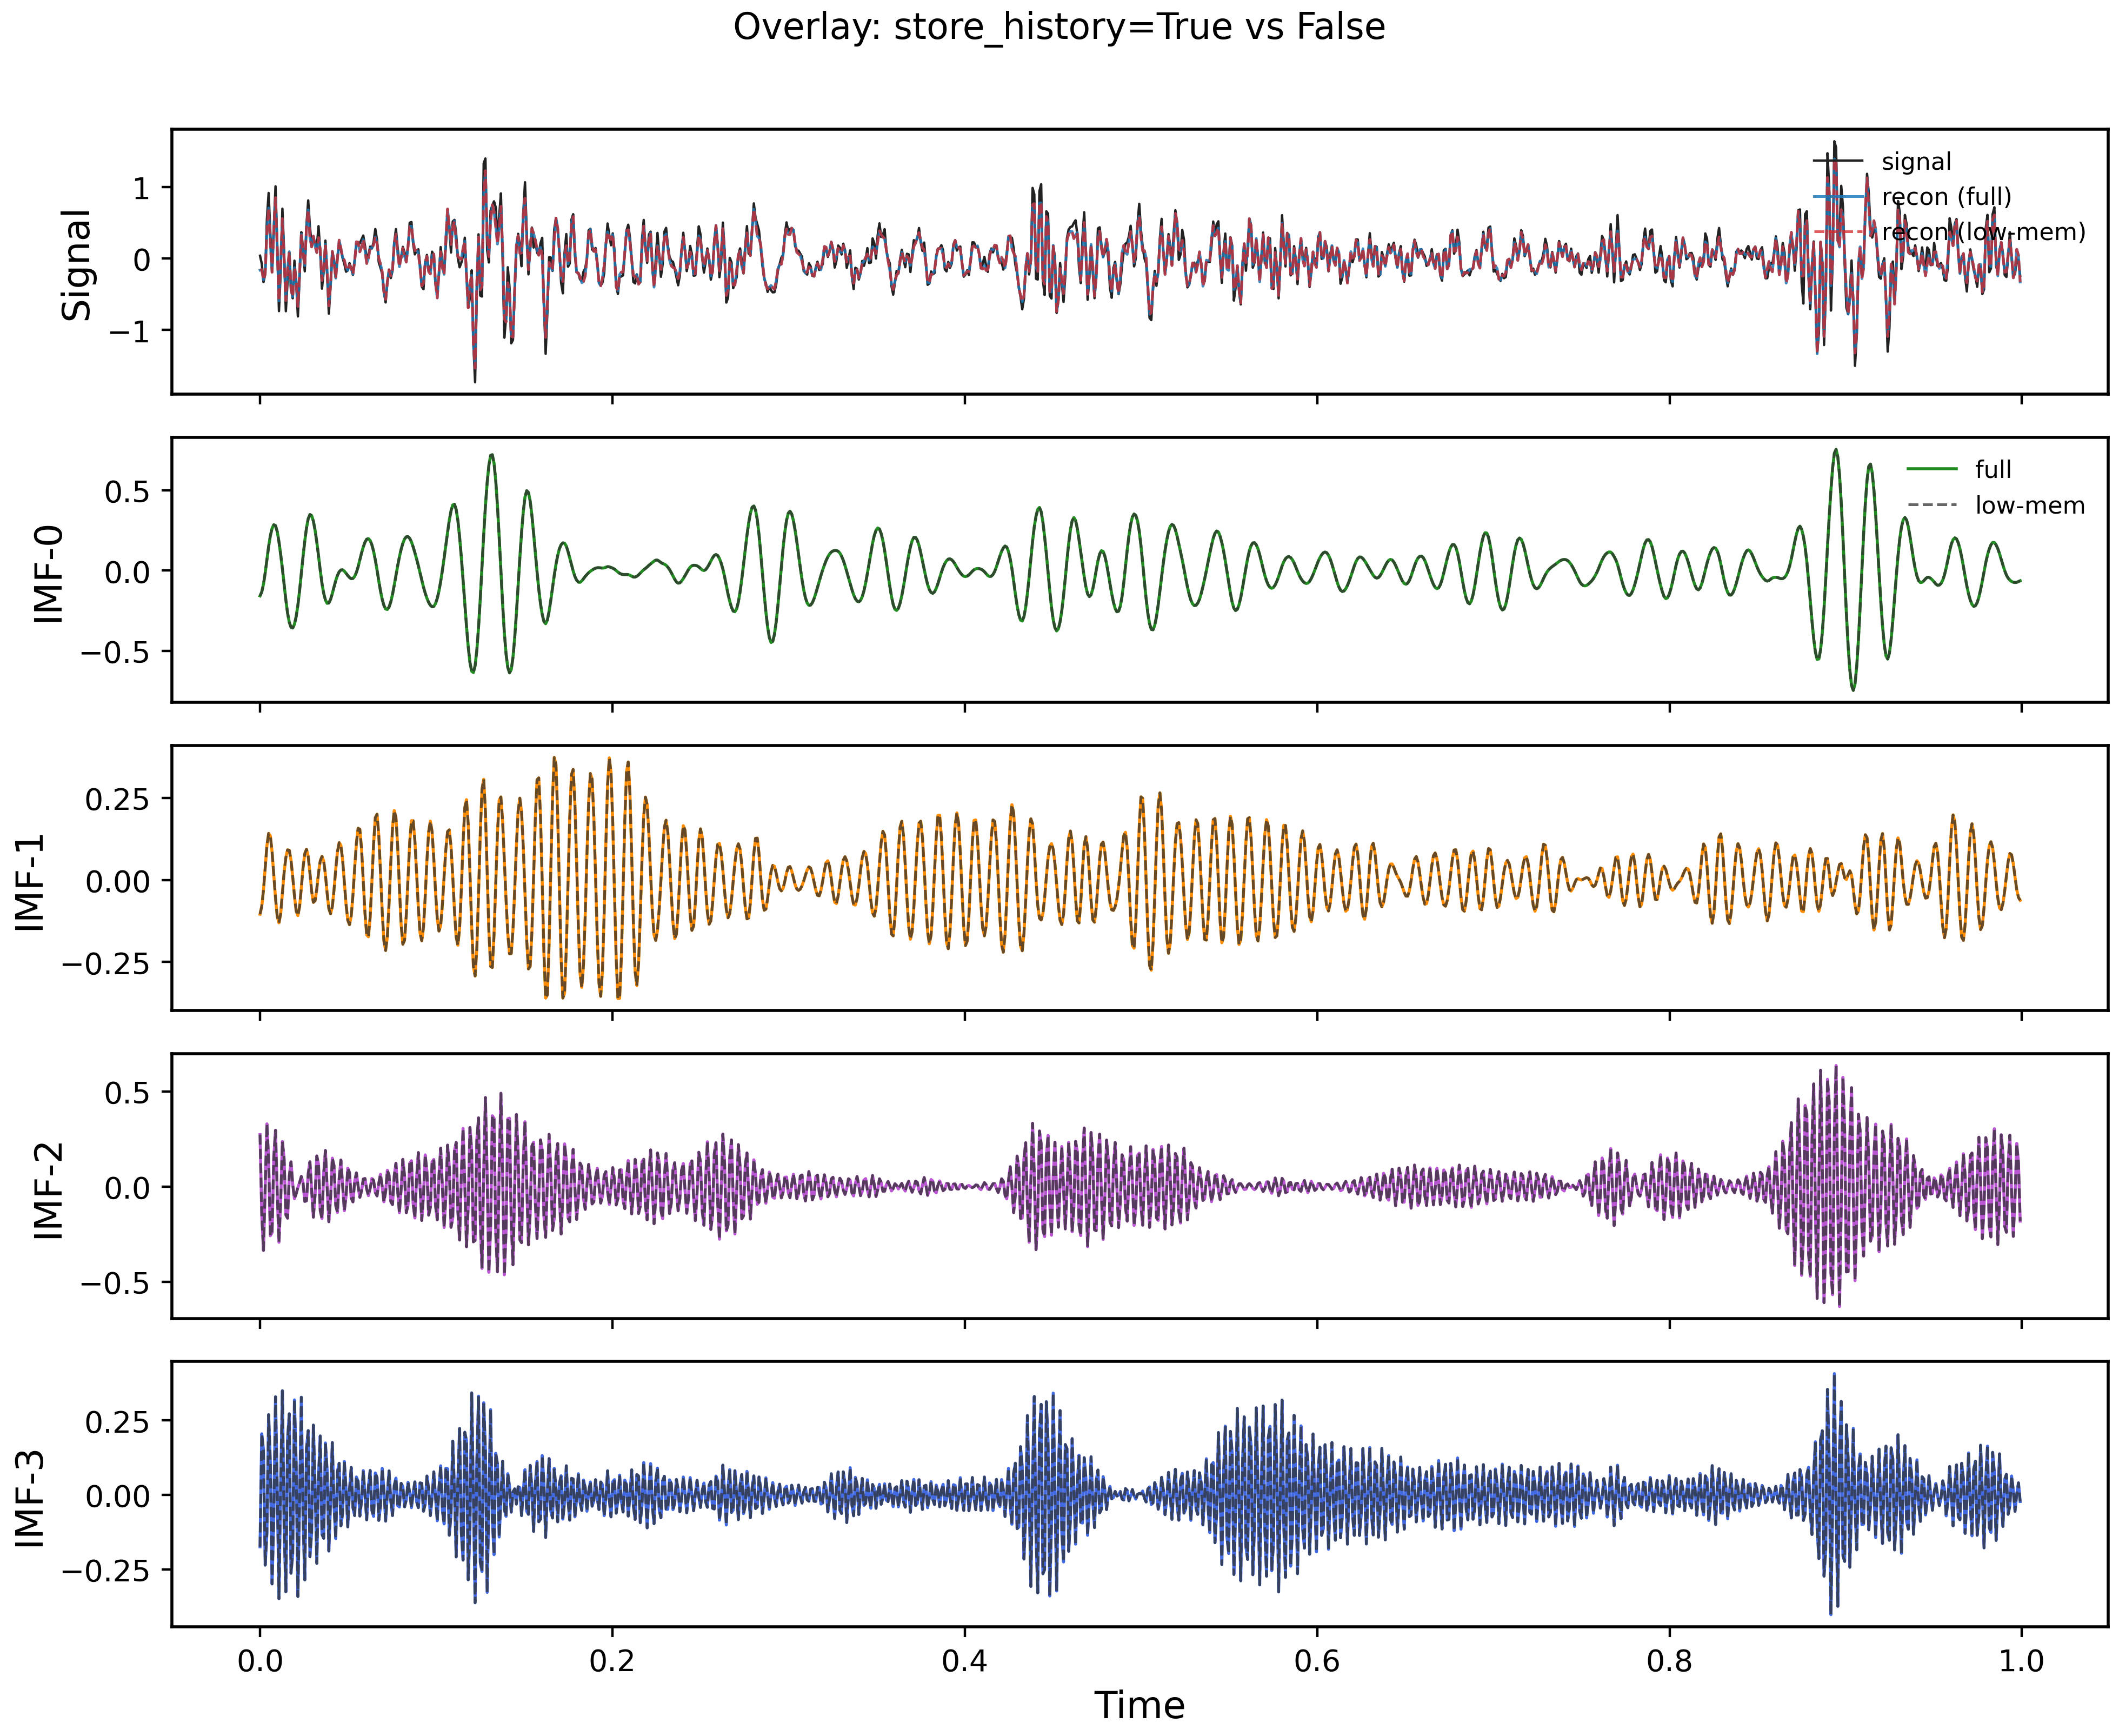

In [5]:
n_modes = full["u"].shape[0]
colors = ["#228B22", "#FF8C00", "#BA55D3", "#4169E1", "#FF6347"]

fig, axes = plt.subplots(n_modes + 1, 1, figsize=(10, 1.6 * (n_modes + 1)), sharex=True)

axes[0].plot(t[: x.size], x, color="#222", lw=0.8, label="signal")
axes[0].plot(
    t[: x.size],
    full["recon"],
    color="#1f77b4",
    lw=0.9,
    alpha=0.85,
    label="recon (full)",
)
axes[0].plot(
    t[: x.size],
    low["recon"],
    color="#d62728",
    lw=0.9,
    alpha=0.75,
    ls="--",
    label="recon (low-mem)",
)
axes[0].set_ylabel("Signal")
axes[0].legend(loc="upper right", fontsize=8, frameon=False)

for k in range(n_modes):
    ax = axes[k + 1]
    c = colors[k % len(colors)]
    ax.plot(t[: x.size], full["u"][k], color=c, lw=1.0, label="full")
    ax.plot(
        t[: x.size],
        low["u"][k],
        color="#333",
        lw=0.9,
        alpha=0.75,
        ls="--",
        label="low-mem",
    )
    ax.set_ylabel(f"IMF-{k}")
    if k == 0:
        ax.legend(loc="upper right", fontsize=8, frameon=False)

axes[-1].set_xlabel("Time")
fig.suptitle("Overlay: store_history=True vs False", y=1.01)
plt.tight_layout()
plt.show()

## 5. Absolute difference of each mode

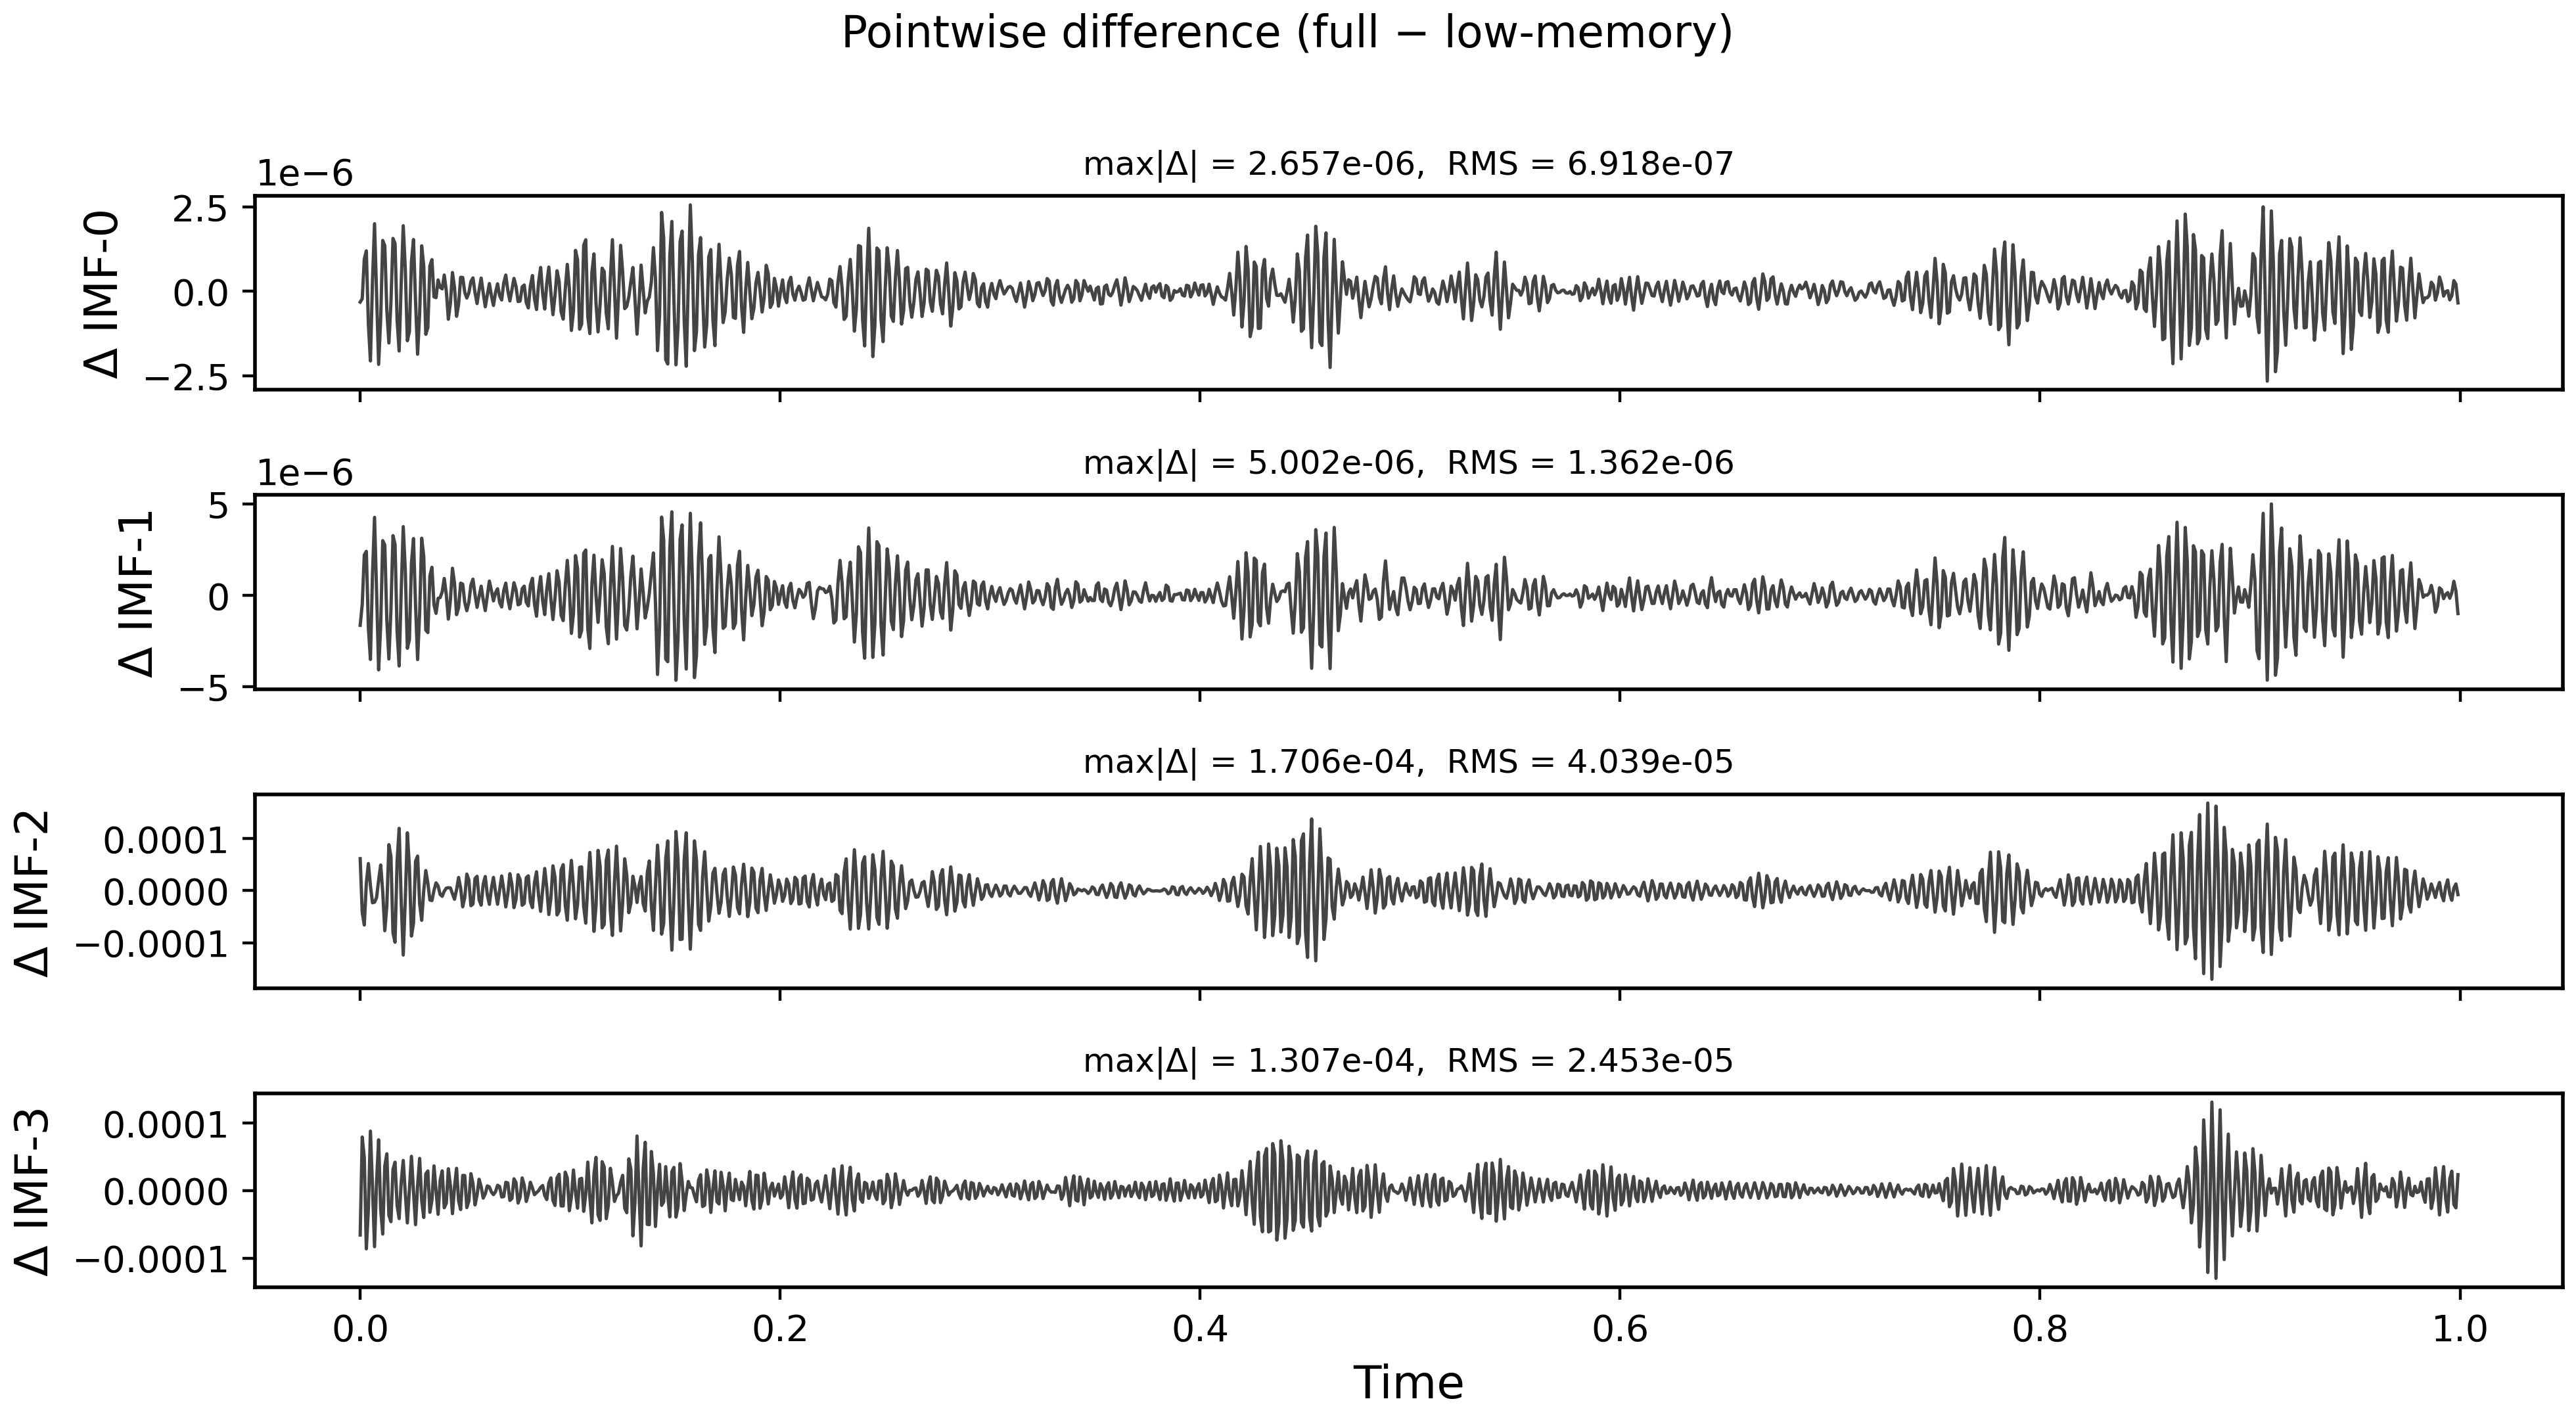

In [6]:
fig, axes = plt.subplots(n_modes, 1, figsize=(10, 1.35 * n_modes), sharex=True)
if n_modes == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    diff = full["u"][k] - low["u"][k]
    ax.plot(t[: x.size], diff, color="#444", lw=0.9)
    ax.set_ylabel(f"Δ IMF-{k}")
    ax.set_title(
        f"max|Δ| = {np.max(np.abs(diff)):.3e},  RMS = {np.sqrt(np.mean(diff**2)):.3e}",
        fontsize=9,
    )

axes[-1].set_xlabel("Time")
fig.suptitle("Pointwise difference (full − low-memory)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Center-frequency trajectories

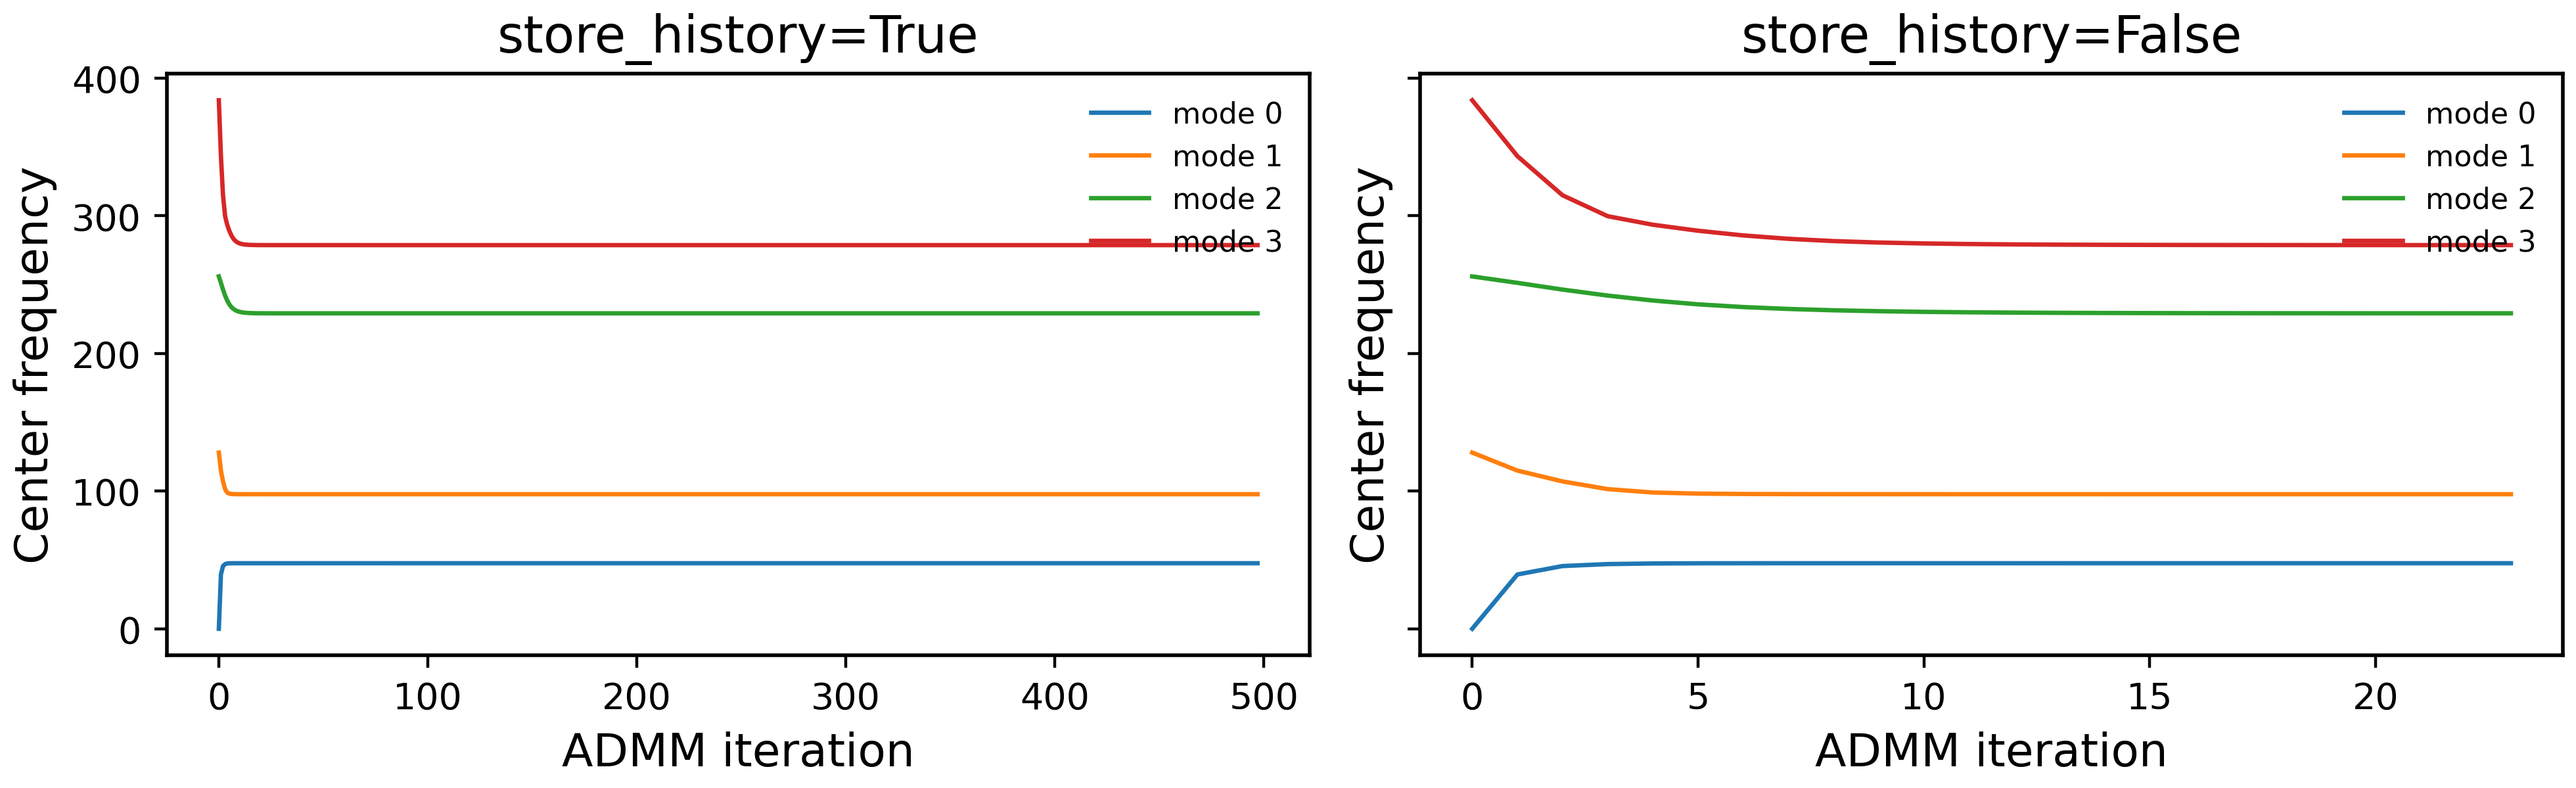

Final center frequencies (cycles / record units):
  full : [ 47.5999  97.7534 229.1925 278.7366]
  low  : [ 47.5999  97.7535 229.1996 278.7427]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)

for ax, result, title in [
    (axes[0], full, "store_history=True"),
    (axes[1], low, "store_history=False"),
]:
    omega = result["omega"]
    for k in range(omega.shape[1]):
        ax.plot(omega[:, k] * fs, label=f"mode {k}", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("ADMM iteration")
    ax.set_ylabel("Center frequency")
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

print("Final center frequencies (cycles / record units):")
print("  full :", np.round(full["omega"][-1] * fs, 4))
print("  low  :", np.round(low["omega"][-1] * fs, 4))

## 7. Summary bar chart

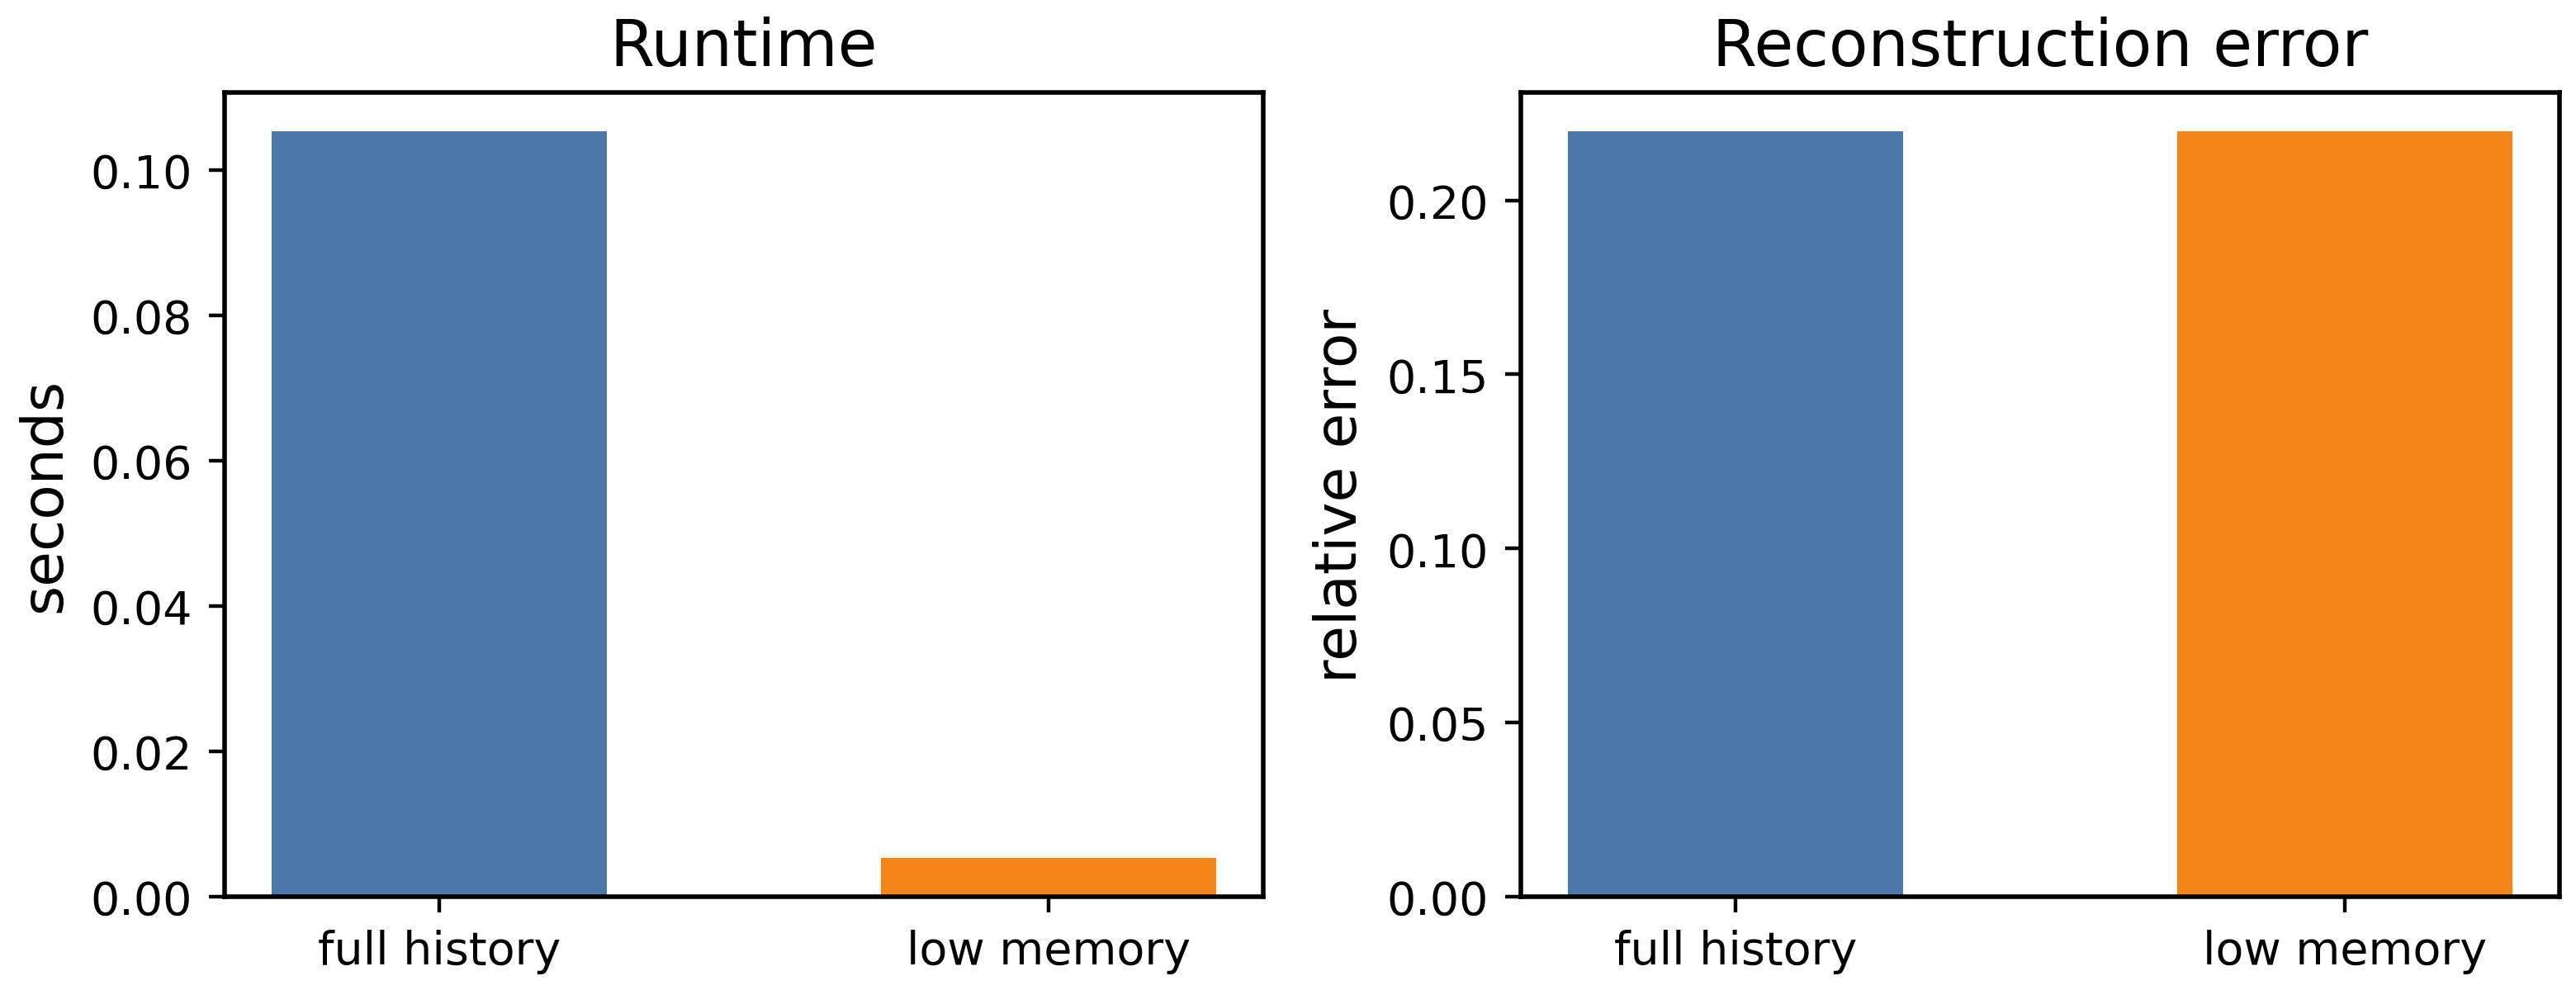

Takeaways:
1) Reconstruction error of the two paths is essentially the same on this signal.
2) Mode waveforms nearly overlap (see overlays / ΔIMF plots).
3) Runtime can differ mainly because low-memory uses a clearer per-iteration
   residual and may early-stop sooner; see the next section for a fair timing test.
4) Peak memory is much lower with store_history=False on long records.


In [8]:
labels = ["time (s)", "rel. recon err"]
full_vals = [full["elapsed"], full["rel_err"]]
low_vals = [low["elapsed"], low["rel_err"]]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

axes[0].bar(
    [0, 1],
    [full["elapsed"], low["elapsed"]],
    color=["#4C78A8", "#F58518"],
    width=0.55,
)
axes[0].set_xticks([0, 1], ["full history", "low memory"])
axes[0].set_ylabel("seconds")
axes[0].set_title("Runtime")

axes[1].bar(
    [0, 1],
    [full["rel_err"], low["rel_err"]],
    color=["#4C78A8", "#F58518"],
    width=0.55,
)
axes[1].set_xticks([0, 1], ["full history", "low memory"])
axes[1].set_ylabel("relative error")
axes[1].set_title("Reconstruction error")

plt.tight_layout()
plt.show()

print(
    "Takeaways:\n"
    "1) Reconstruction error of the two paths is essentially the same on this signal.\n"
    "2) Mode waveforms nearly overlap (see overlays / ΔIMF plots).\n"
    "3) Runtime can differ mainly because low-memory uses a clearer per-iteration\n"
    "   residual and may early-stop sooner; see the next section for a fair timing test.\n"
    "4) Peak memory is much lower with store_history=False on long records."
)

## 8. Fair timing with early-stop disabled

The low-memory path uses a per-iteration residual and may stop earlier than the legacy accumulator. Below we set an extremely tight `tol` so both paths run essentially all `max_iter` steps, isolating buffering cost from early-stopping.

Forced nearly-full iterations (tol=0, max_iter=200)
  full : time=0.0392s, rel_err=2.199e-01, omega_rows=198
  low  : time=0.0352s, rel_err=2.199e-01, omega_rows=199
  relative IMF difference = 0.000e+00


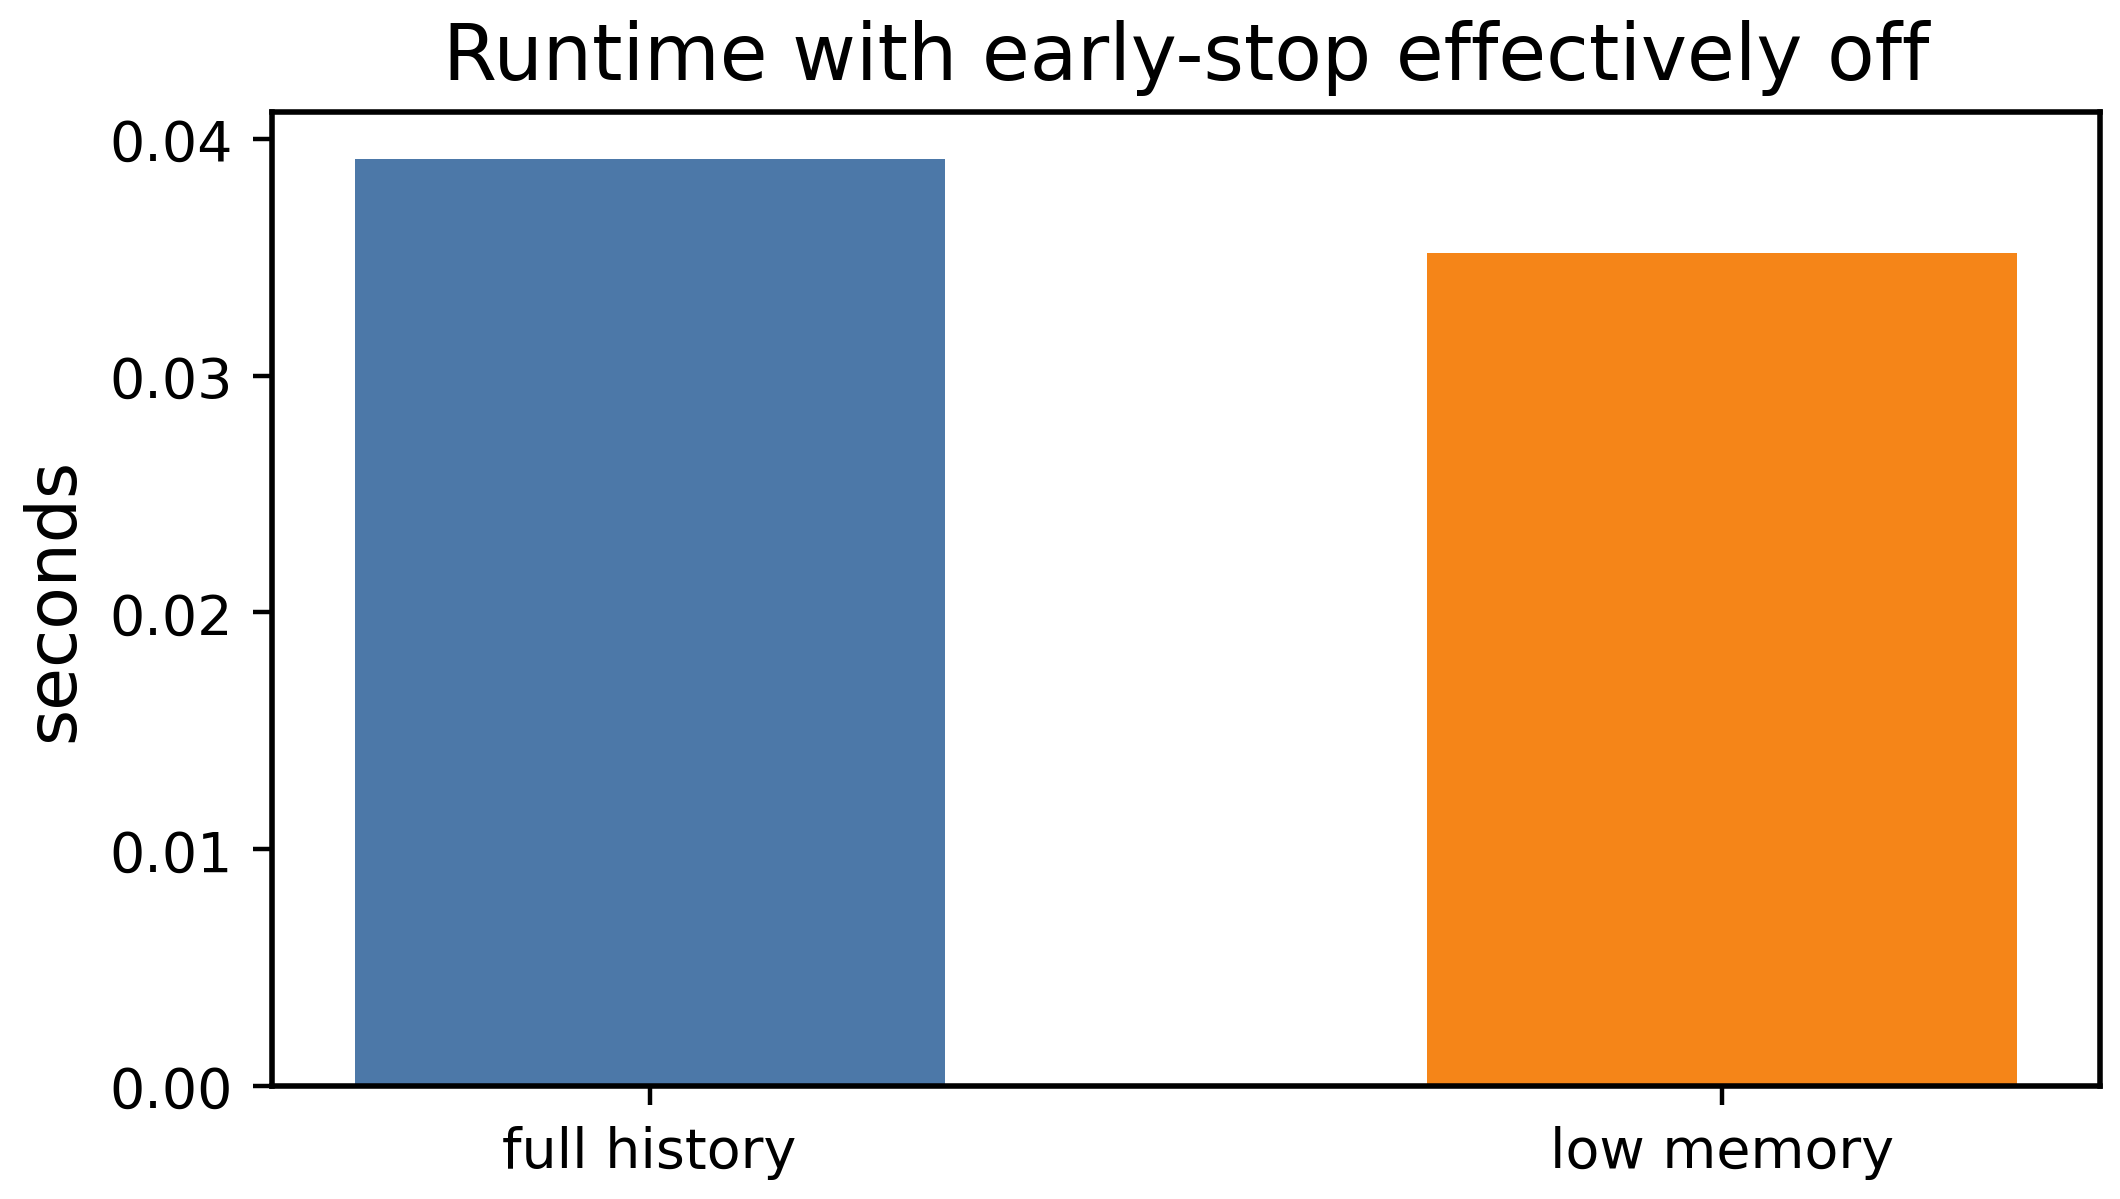

In [9]:
def run_vmd_forced(store_history: bool, max_iter_run: int = 200, tol_run: float = 0.0):
    vmd = VMD(
        alpha=alpha,
        K=K,
        tau=tau,
        init="uniform",
        max_iter=max_iter_run,
        tol=tol_run,
        store_history=store_history,
    )
    t0 = time.perf_counter()
    u, _, omega = vmd.fit_transform(signal, return_all=True)
    elapsed = time.perf_counter() - t0
    recon = np.sum(u, axis=0)
    x_ = signal[: recon.size]
    rel_err = np.linalg.norm(recon - x_) / (np.linalg.norm(x_) + 1e-12)
    return elapsed, rel_err, omega.shape[0], u


t_full, e_full, n_full, u_full = run_vmd_forced(True)
t_low, e_low, n_low, u_low = run_vmd_forced(False)

print("Forced nearly-full iterations (tol=0, max_iter=200)")
print(f"  full : time={t_full:.4f}s, rel_err={e_full:.3e}, omega_rows={n_full}")
print(f"  low  : time={t_low:.4f}s, rel_err={e_low:.3e}, omega_rows={n_low}")
print(
    f"  relative IMF difference = "
    f"{np.linalg.norm(u_full - u_low) / (np.linalg.norm(u_full) + 1e-12):.3e}"
)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(
    [0, 1],
    [t_full, t_low],
    color=["#4C78A8", "#F58518"],
    width=0.55,
)
ax.set_xticks([0, 1], ["full history", "low memory"])
ax.set_ylabel("seconds")
ax.set_title("Runtime with early-stop effectively off")
plt.tight_layout()
plt.show()